In [1]:
import pandas as pd
df = pd.read_csv("../data/fraud_data.csv")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y)
X = df.drop(columns=["transaction_id", "merchant_category", "is_fraud"])
y = df["is_fraud"]

# Split into train and test sets
# stratify=y keeps the same fraud/non-fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nFraud % in train:", y_train.mean() * 100)
print("Fraud % in test:", y_test.mean() * 100)

Training set size: (8000, 7)
Test set size: (2000, 7)

Fraud % in train: 1.5125
Fraud % in test: 1.5


In [3]:
# class_weight = 'balanced' tells the model to pay more attention
# to the rare fraud class instead of ignoring it
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate - using classification_report instead of just accuracy
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      1.00      0.42        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000



In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# class_weight="balanced" works the same way here too
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.67      0.80        30

    accuracy                           0.99      2000
   macro avg       1.00      0.83      0.90      2000
weighted avg       1.00      0.99      0.99      2000



Saved!


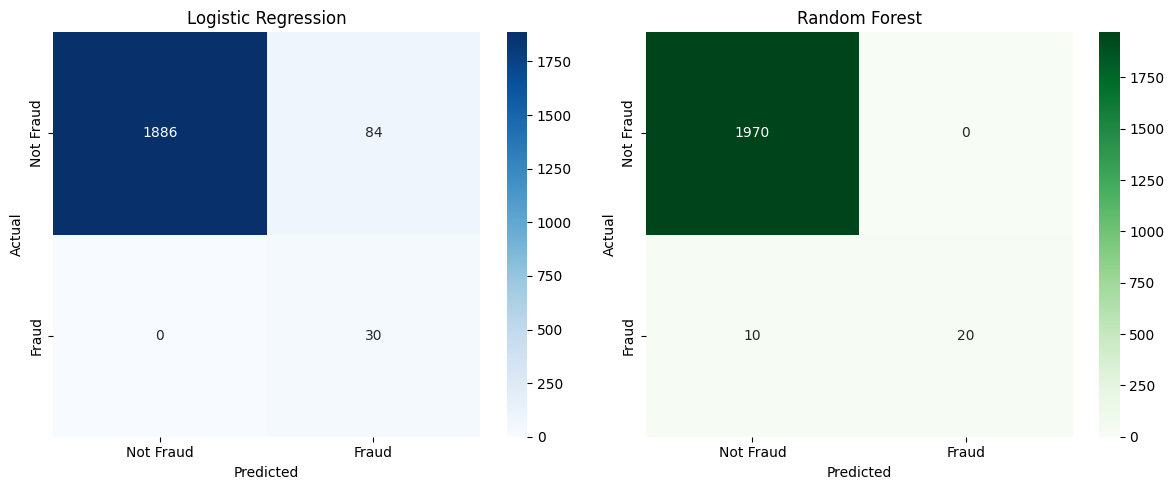

In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get confusion matrices for both models
cm_lr = confusion_matrix(y_test, y_pred)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
axes[0].set_title("Logistic Regression")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
axes[1].set_title("Random Forest")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../output/confusion_matrices.png", dpi=150)
print("Saved!")
plt.show()